<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/***Municipality%20Merge%20(ps01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [2]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [3]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [4]:
#NJ Office of GIS (March 14, 2025), Municipal Boundaries of NJ, Hosted, 3857
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::municipal-boundaries-of-nj-hosted-3857/about)
#code used from class
! wget -q -O NJ_Municipalities_3857_-3177345712037447640.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/NJ_Municipalities_3857_-3177345712037447640.zip

zip_ref = zipfile.ZipFile('NJ_Municipalities_3857_-3177345712037447640.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njMun=gpd.read_file('NJ_Municipalities_3857.shp') #labeled shapefile njSch

In [5]:
njMun1=njMun [['COUNTY','MUN','geometry']]
njMun1

,COUNTY,MUN,geometry
0,CAPE MAY,CAPE MAY POINT BORO,"POLYGON ((-8344490.563 4711880.915, -8344514.7..."
1,CAPE MAY,WEST CAPE MAY BORO,"POLYGON ((-8340707.056 4713628.495, -8340189.7..."
2,CAPE MAY,CAPE MAY CITY,"POLYGON ((-8335214.076 4714789.319, -8335184.0..."
3,CAPE MAY,WILDWOOD CREST BORO,"POLYGON ((-8330406.396 4719677.644, -8330406.2..."
4,CAPE MAY,WEST WILDWOOD BORO,"POLYGON ((-8328802.263 4722008.337, -8328767.1..."
...,...,...,...
559,MIDDLESEX,MIDDLESEX BORO,"POLYGON ((-8290689.759 4951810.864, -8290685.3..."
560,MIDDLESEX,HIGHLAND PARK BORO,"POLYGON ((-8284996.194 4939671.234, -8284993.5..."
561,MIDDLESEX,EDISON TWP,"POLYGON ((-8274473.052 4948504.318, -8274258.1..."
562,MIDDLESEX,METUCHEN BORO,"POLYGON ((-8278823.62 4943156.217, -8279626.76..."


In [6]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Economically%20Disadvantage%20Youth%202024%20-%202025.xlsx', header = 3)

In [7]:
DisXls1=DisXls [['CountyName','DistrictName','Economically Disadvantaged Students']]
DisXls1.rename(columns={'CountyName' : 'COUNTY'}, inplace=True)
DisXls1.rename(columns={'DistrictName' : 'MUN'}, inplace=True)
DisXls1

/tmp/ipykernel_1612/2995246507.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1.rename(columns={'CountyName' : 'COUNTY'}, inplace=True)
/tmp/ipykernel_1612/2995246507.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1.rename(columns={'DistrictName' : 'MUN'}, inplace=True)


,COUNTY,MUN,Economically Disadvantaged Students
0,Camden,Audubon Public School District,24.5%
1,Camden,Barrington School District,34.1%
2,Camden,Bellmawr Public School District,57.8%
3,Camden,Berlin Borough School District,25.2%
4,Camden,Berlin Township School District,53.3%
5,Camden,Black Horse Pike Regional School District,44.9%
6,Camden,Brooklawn Public School District,70.7%
7,Camden,Camden City School District,88.5%
8,Camden,Camden County Technical School District,56.1%
9,Camden,Cherry Hill School District,23.2%


In [8]:
#njMun1[['MUN','GEOID']]
#code from class to strip white space for merging
DisXls1['c']=DisXls1.MUN.str.strip()
njMun1['c']=njMun1.MUN.str.strip()

/tmp/ipykernel_1612/1867066976.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1['c']=DisXls1.MUN.str.strip()
/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [9]:
#code from Gemini to make all upper case for merging
DisXls1['MUN'] = DisXls1['MUN'].str.upper()
DisXls1['COUNTY'] = DisXls1['COUNTY'].str.upper()
njMun1['MUN'] = njMun1['MUN'].str.upper()
njMun1['first_word_MUN'] = njMun1['MUN'].str.split().str[0]

/tmp/ipykernel_1612/2970970629.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1['MUN'] = DisXls1['MUN'].str.upper()
/tmp/ipykernel_1612/2970970629.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1['COUNTY'] = DisXls1['COUNTY'].str.upper()
/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

In [10]:
#code from Gemini to match only the first word which is the name of the school and municipality
DisXls1['first_word_MUN'] = DisXls1['MUN'].str.split().str[0]

/tmp/ipykernel_1612/2009520454.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1['first_word_MUN'] = DisXls1['MUN'].str.split().str[0]


In [11]:
#merged newly created column "first_word_MUN", MUN and Camden County
a1 = pd.merge(njMun1, DisXls1, left_on=['first_word_MUN', 'COUNTY'], right_on=['first_word_MUN', 'COUNTY'], how='outer', indicator=True)
a1

,COUNTY,MUN_x,geometry,c_x,first_word_MUN,MUN_y,Economically Disadvantaged Students,c_y,_merge
0,MONMOUTH,ABERDEEN TWP,"MULTIPOLYGON (((-8264740.14 4923810.315, -8264...",ABERDEEN TWP,ABERDEEN,NaN,NaN,NaN,left_only
1,ATLANTIC,ABSECON CITY,"POLYGON ((-8288862.436 4782611.884, -8288980.6...",ABSECON CITY,ABSECON,NaN,NaN,NaN,left_only
2,HUNTERDON,ALEXANDRIA TWP,"POLYGON ((-8357617.176 4959782.91, -8357607.87...",ALEXANDRIA TWP,ALEXANDRIA,NaN,NaN,NaN,left_only
3,WARREN,ALLAMUCHY TWP,"POLYGON ((-8328378.179 5005463.668, -8327730.0...",ALLAMUCHY TWP,ALLAMUCHY,NaN,NaN,NaN,left_only
4,BERGEN,ALLENDALE BORO,"POLYGON ((-8250400.664 5018755.571, -8250410.4...",ALLENDALE BORO,ALLENDALE,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...
574,CAMDEN,WOODLYNNE BORO,"POLYGON ((-8359636.911 4853402.831, -8359670.4...",WOODLYNNE BORO,WOODLYNNE,WOODLYNNE SCHOOL DISTRICT,80.6%,Woodlynne School District,both
575,SALEM,WOODSTOWN BORO,"POLYGON ((-8385992.983 4813445.29, -8386390.73...",WOODSTOWN BORO,WOODSTOWN,NaN,NaN,NaN,left_only
576,GLOUCESTER,WOOLWICH TWP,"POLYGON ((-8380771.89 4835363.563, -8380774.63...",WOOLWICH TWP,WOOLWICH,NaN,NaN,NaN,left_only
577,BURLINGTON,WRIGHTSTOWN BORO,"MULTIPOLYGON (((-8306554.986 4865095.416, -830...",WRIGHTSTOWN BORO,WRIGHTSTOWN,NaN,NaN,NaN,left_only


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [12]:
a1._merge.value_counts()

,count
_merge,
left_only,532
both,38
right_only,9


<Axes: >

Text(0.5, 1.0, '% of Economically Disadvantaged Students\n2024 - 2025 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

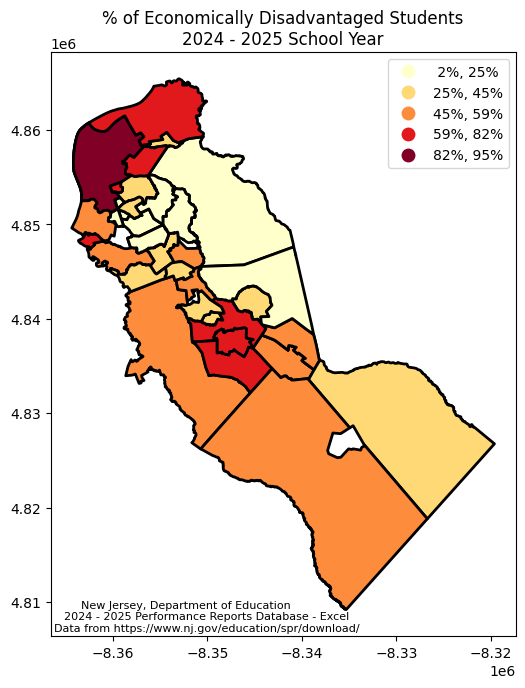

In [15]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['Economically Disadvantaged Students'] = a1['Economically Disadvantaged Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='Economically Disadvantaged Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Economically Disadvantaged Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )